In [2]:
import os
import shutil
from pathlib import Path

# Full class names for better readability in your paper
class_mapping = {
    'AD': 'Atopic Dermatitis',
    'CD': 'Contact Dermatitis',
    'EC': 'Eczema',
    'SC': 'Scabies',
    'SD': 'Seborrheic Dermatitis',
    'TC': 'Tinea Corporis'
}

# Create clean folder
data_dir = Path('/content/data/train')
data_dir.mkdir(parents=True, exist_ok=True)

print("🚀 Copying and renaming classes to clean structure...\n")

total_copied = 0
for short_code, full_name in class_mapping.items():
    src_folder = Path('/content/drive/MyDrive/CVPR_Research/SkinDestNet/Augmented') / short_code
    dest_folder = data_dir / full_name
    dest_folder.mkdir(parents=True, exist_ok=True)

    if src_folder.exists():
        images = list(src_folder.glob('*.[jJpP][pPnN][gG]'))
        for img in images:
            shutil.copy(img, dest_folder / img.name)
        print(f"✅ {full_name:25s} ← {len(images):4d} images")
        total_copied += len(images)
    else:
        print(f"⚠️  Missing folder: {short_code}")

print(f"\n🎉 DONE! Total images copied: {total_copied}")
print(f"Clean dataset ready at: /content/data/train/")
!ls /content/data/train/


🚀 Copying and renaming classes to clean structure...

✅ Atopic Dermatitis         ←  490 images
✅ Contact Dermatitis        ← 3339 images
✅ Eczema                    ← 3262 images
✅ Scabies                   ← 2401 images
✅ Seborrheic Dermatitis     ←  553 images
✅ Tinea Corporis            ← 1925 images

🎉 DONE! Total images copied: 11970
Clean dataset ready at: /content/data/train/
'Atopic Dermatitis'    Eczema	'Seborrheic Dermatitis'
'Contact Dermatitis'   Scabies	'Tinea Corporis'


In [3]:
##Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
print("Libraries has been imported successfully")


Libraries has been imported successfully


In [4]:
### Data Preprocessing
# In this step, the images are resized to 224×224 and normalized.
# Normalization helps the model learn faster and improves performance.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [5]:
## Dataset Loading
# The Bangladesh-specific SkinDisNet (Augmented) dataset is loaded using ImageFolder.
# It contains 6 different classes of skin lesions captured in clinical settings in Bangladesh.
full_dataset = ImageFolder(root='/content/data/train', transform=transform)

print(f"Training data size: {len(full_dataset)}")

classes = full_dataset.classes
print(f"Classes: {classes}")


Training data size: 11970
Classes: ['Atopic Dermatitis', 'Contact Dermatitis', 'Eczema', 'Scabies', 'Seborrheic Dermatitis', 'Tinea Corporis']


In [6]:
## Train-Validation Split
# The dataset is divided into training and validation sets.
# 80% is used for training and 20% for validation.
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_data, val_data, test_data = random_split(full_dataset, [train_size, val_size, test_size])

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)



Training samples: 9576
Validation samples: 1197
Test samples: 1197


In [7]:
## CNN Model
# A Lightweight Attention-Based Convolutional Neural Network (CNN) is defined.
# It consists of convolution layers, Squeeze-and-Excitation attention, pooling, and fully connected layers for classification.
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)
    def forward(self, x):
        b, c, _, _ = x.size()
        y = F.adaptive_avg_pool2d(x, 1).view(b, c)
        y = F.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y)).view(b, c, 1, 1)
        return x * y

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.se1 = SEBlock(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.se2 = SEBlock(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 56 * 56, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 6)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.se1(x)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.se2(x)
        x = x.view(-1, 64 * 56 * 56)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
print(f"Model is running on: {device}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)


Model is running on: cpu


In [9]:
## Training Process
# The model is trained using cross-entropy loss and Adam optimizer.
# Accuracy and loss are calculated for both training and validation data.
train_losses = []
val_losses = []
train_acc = []
val_acc = []

num_epochs = 10

print("Starting training")
print("-" * 50)

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_acc.append(100 * correct / total)

    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_losses.append(val_loss / len(val_loader))
    val_acc.append(100 * correct / total)

    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f" Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc[-1]:.2f}%")
    print(f" Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_acc[-1]:.2f}%")
    print("-" * 30)

print("Training completed")



Starting training
--------------------------------------------------
Epoch 1/10
 Train Loss: 1.5485, Train Acc: 28.58%
 Val Loss: 1.5335, Val Acc: 27.15%
------------------------------
Epoch 2/10
 Train Loss: 1.5499, Train Acc: 28.40%
 Val Loss: 1.4975, Val Acc: 27.74%
------------------------------
Epoch 3/10
 Train Loss: 1.5293, Train Acc: 28.20%
 Val Loss: 1.4797, Val Acc: 28.74%
------------------------------
Epoch 4/10
 Train Loss: 1.5297, Train Acc: 28.21%
 Val Loss: 1.4831, Val Acc: 36.84%
------------------------------
Epoch 5/10
 Train Loss: 1.5242, Train Acc: 29.50%
 Val Loss: 1.4938, Val Acc: 37.51%
------------------------------
Epoch 6/10
 Train Loss: 1.5153, Train Acc: 29.76%
 Val Loss: 1.4831, Val Acc: 36.17%
------------------------------
Epoch 7/10
 Train Loss: 1.5174, Train Acc: 29.48%
 Val Loss: 1.4796, Val Acc: 34.75%
------------------------------
Epoch 8/10
 Train Loss: 1.5086, Train Acc: 30.32%
 Val Loss: 1.4599, Val Acc: 37.68%
------------------------------
Epo

In [10]:
## Model Evaluation
# After training, the model is tested on unseen data to measure its accuracy.
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))


Test Accuracy: 37.68%

Classification Report:
                       precision    recall  f1-score   support

    Atopic Dermatitis       0.00      0.00      0.00        53
   Contact Dermatitis       0.38      0.62      0.47       334
               Eczema       0.48      0.15      0.22       324
              Scabies       0.35      0.83      0.49       239
Seborrheic Dermatitis       0.00      0.00      0.00        50
       Tinea Corporis       0.00      0.00      0.00       197

             accuracy                           0.38      1197
            macro avg       0.20      0.27      0.20      1197
         weighted avg       0.31      0.38      0.29      1197



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


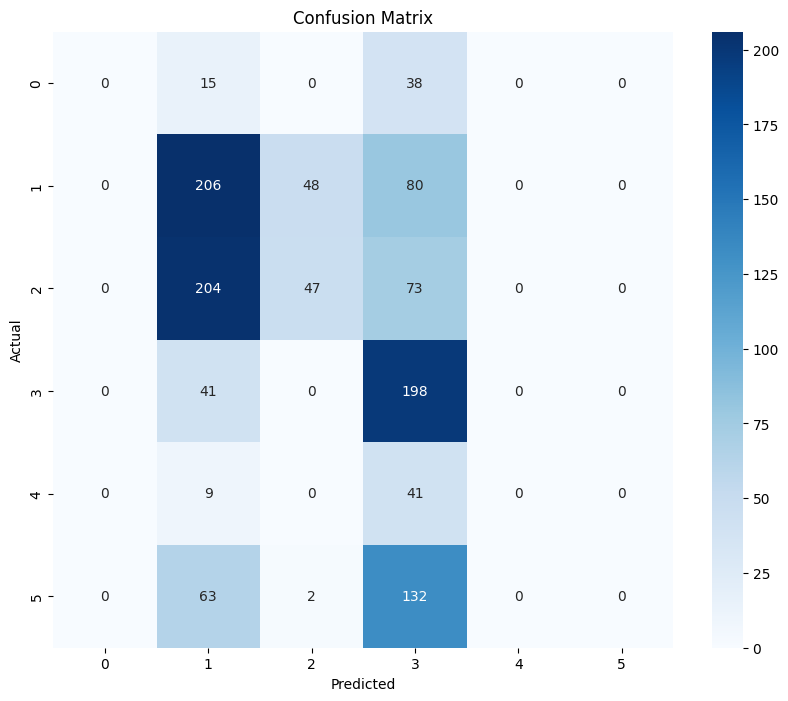


Per-class Accuracy:
Atopic Dermatitis        : 0.00%
Contact Dermatitis       : 61.68%
Eczema                   : 14.51%
Scabies                  : 82.85%
Seborrheic Dermatitis    : 0.00%
Tinea Corporis           : 0.00%

Best performing class: Scabies
Worst performing class: Atopic Dermatitis


In [12]:
## Confusion Matrix
# The confusion matrix shows how well the model predicts each class.
# It helps identify correct and incorrect predictions.
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

per_class_acc = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class Accuracy:")
for i, class_name in enumerate(classes):
    print(f"{class_name:25s}: {per_class_acc[i]:.2%}")

best_class = classes[np.argmax(per_class_acc)]
worst_class = classes[np.argmin(per_class_acc)]
print(f"\nBest performing class: {best_class}")
print(f"Worst performing class: {worst_class}")



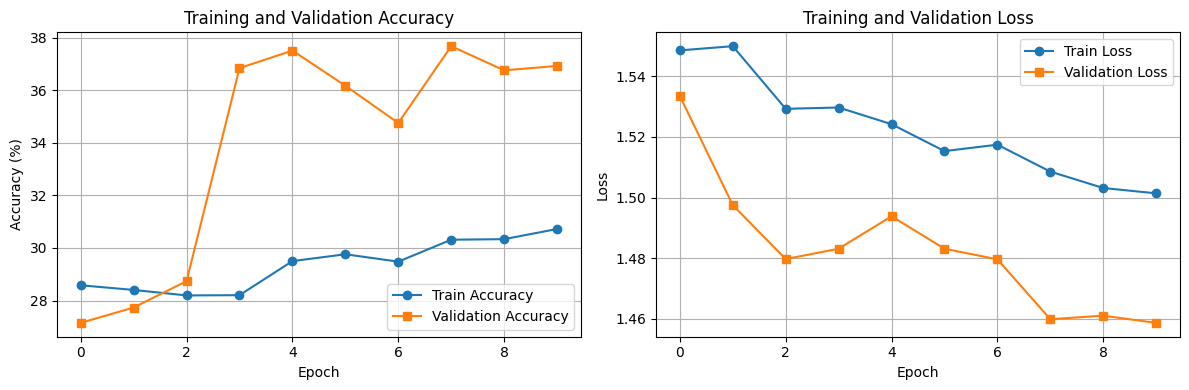

Model saved as 'lightweight_attention_cnn_skandisnet.pth'


In [13]:
## Training Curves
# Graphs are plotted to visualize training and validation accuracy and loss over epochs.
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Accuracy', marker='o')
plt.plot(val_acc, label='Validation Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

torch.save(model.state_dict(), "lightweight_attention_cnn_skandisnet.pth")
print("Model saved as 'lightweight_attention_cnn_skandisnet.pth'")
